# Домашнее задание 2. База знаний и память для агента

Корпус: полные тексты 47 обзорных страниц Википедии про 2026 год, из которых собраны вопросы первой домашки. Вопросы те же, 148 штук с цитатой `evidence`, плюс 10 вопросов без ответа в корпусе. Код лежит в пакете `rag/`, агент и клиент OpenRouter берутся из первой домашки (`1_week_react/practice/src`). Дорогие прогоны сделаны скриптом `run_eval.py` и закэшированы в `results/*.csv`, ноутбук их только читает; эмбеддинги берутся из кэша `data/embeddings_cache.npz`, так что повторный запуск ноутбука почти ничего не стоит.

Milvus поднят через `docker-compose.yml` (`docker compose up -d`). Если сервера нет, задайте `MILVUS_URI=data/milvus_lite.db` — тот же код заработает на Milvus Lite.

In [1]:
import sys, json, time
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from rag import (DATA, IMG, RESULTS, MODELS, COLORS, EMBED_MODEL, DIM, make_settings, load_jsonl, Ledger, LLMClient,
                 chunk_corpus, chunk_lines, chunk_chars, emb_text, torn_example, EmbeddingCache, VectorStore,
                 search_numpy, rank_numpy, recall_curve, recall_at, is_gold, build_keyword_index, keyword_search, rrf)
from rag.rag import Retriever, RagAnswerer, PlainAnswerer, AgentAnswerer, make_registry, format_sources, KBArgs, KB_DESCRIPTION
from rag.evaluation import evaluate, report, refusal_table, diagnose, last_week_rows, final_answer
from rag.memory import EpisodicJournal, SemanticMemory, MemoryAssistant, extract_facts
from rag.viz import recall_chart, hybrid_chart, money_chart, tokens_chart, similarity_chart, chunk_length_chart
from rag.hw1 import WEEK1, show_trace

settings = make_settings()
ledger = Ledger()
client = LLMClient(settings, ledger)
corpus, tasks, unanswerable = load_jsonl("corpus.jsonl"), load_jsonl("questions.jsonl"), load_jsonl("unanswerable.jsonl")
len(corpus), sum(len(p["text"]) for p in corpus), len(tasks), len(unanswerable), tasks[0]

/Users/kiri.kozlov/Desktop/courses/ai_agents_postypachki_2026/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(47,
 1024797,
 148,
 10,
 {'id': 'fresh-0',
  'source': 'fresh',
  'question': 'On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics?',
  'answer': '15 March',
  'evidence': '15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022.',
  'page': '2026 in Ukraine',
  'url': 'https://en.wikipedia.org/wiki/2026_in_Ukraine',
  'agent_ok': True})

## Шаг 1. Корпус и две нарезки

Наивная нарезка: по 400 символов подряд, не глядя на границы. Осмысленная: одна строка страницы это одно датированное событие, поэтому граница куска проходит по переводу строки, а заголовок раздела (месяц или тема) едет с куском как метаданные `section`. У каждого куска есть `page`, `section`, `url` и номер строки `line_no`, по которым человек найдёт источник.

кусков по строкам: 7084, по 400 символов: 2577
{'page': '2026 in Australia', 'section': 'February', 'url': 'https://en.wikipedia.org/wiki/2026_in_Australia', 'text': '21 February – Daryl Jackson, architect (b. 1937)', 'line_no': 274, 'id': 500}

факт, который наивная нарезка разорвала: On what date did Ukraine boycott the closing ceremony of the 2026 Winter Paralympics? | ответ: 15 March
  кусок 1: ...ment in the defense and energy sectors. 15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest 
  кусок 2: over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 20...


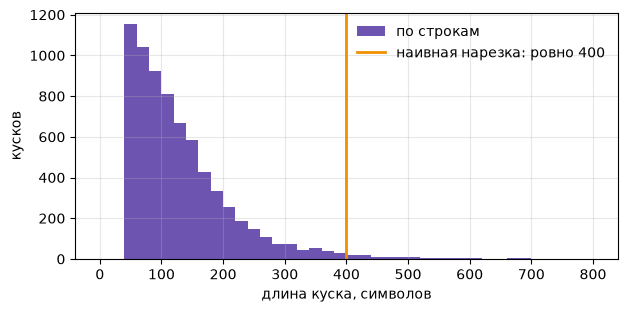

In [2]:
line_chunks, char_chunks = chunk_corpus(corpus, chunk_lines), chunk_corpus(corpus, chunk_chars)
print(f"кусков по строкам: {len(line_chunks)}, по 400 символов: {len(char_chunks)}")
print(line_chunks[500])
task, parts = torn_example(tasks, char_chunks)
print("\nфакт, который наивная нарезка разорвала:", task["question"], "| ответ:", task["answer"])
for n, part in enumerate(parts, 1):
    print(f"  кусок {n}: ...{part[-140:]}" if n == 1 else f"  кусок {n}: {part[:140]}...")
chunk_length_chart(line_chunks, path=IMG / "chunk_lengths.png");

## Шаг 2. Эмбеддинги с кэшем

Ключ кэша это sha1 текста, значение вектор `text-embedding-3-small` на 512 измерений. Сначала загружается файл семинара `embeddings_512.npz` и наш `embeddings_cache.npz`, потом досчитывается только то, чего в них нет. Ниже видно, сколько текстов взято из кэша и сколько пришлось посчитать.

In [3]:
cache = EmbeddingCache(client, DATA / "embeddings_cache.npz", seeds=(DATA / "embeddings_512.npz",))
print("в кэше векторов:", cache.load())
line_vecs = cache.embed([emb_text(c) for c in line_chunks]); print("строки:", line_vecs.shape, "из кэша", cache.last_hits, "посчитано", cache.last_misses)
char_vecs = cache.embed([c["text"] for c in char_chunks]); print("символы:", char_vecs.shape, "из кэша", cache.last_hits, "посчитано", cache.last_misses)
q_vecs = cache.embed([t["question"] for t in tasks]); print("вопросы:", q_vecs.shape, "из кэша", cache.last_hits, "посчитано", cache.last_misses)
cache.save()
ledger.table()

в кэше векторов: 10837
строки: (7084, 512) из кэша 7084 посчитано 0
символы: (2577, 512) из кэша 2577 посчитано 0
вопросы: (148, 512) из кэша 148 посчитано 0


,,calls,prompt,completion,cost,seconds
tag,model,,,,,


## Шаг 3. Качество поиска: recall@k по двум нарезкам

Верным считаем кусок с той же страницы, в котором есть ответ и не меньше половины слов исходной цитаты. Поиск здесь на numpy: векторы нормализованы, косинусная близость это одно умножение матрицы на вектор.

,по строкам,по 400 символов
1,0.885,0.493
3,0.966,0.709
5,0.986,0.797
10,0.986,0.831


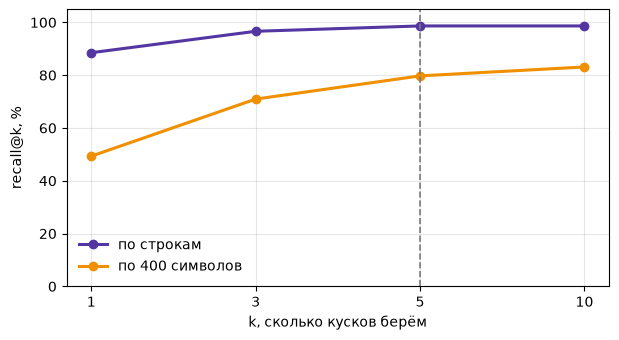

In [4]:
KS = (1, 3, 5, 10)
rank_lines, rank_chars = rank_numpy(q_vecs, line_vecs, 20), rank_numpy(q_vecs, char_vecs, 20)
curves = {"по строкам": recall_curve(rank_lines, line_chunks, tasks, KS), "по 400 символов": recall_curve(rank_chars, char_chunks, tasks, KS)}
K = 5
recall_chart(curves, path=IMG / "recall.png", chosen_k=K)
recall_df = pd.DataFrame(curves).round(3)
recall_df.to_csv(RESULTS / "recall.csv")
recall_df

**Выбор k.** На нарезке по строкам кривая выходит на плато уже при k=5 (recall@5 и recall@10 совпадают), а каждый лишний кусок это ещё 60–80 токенов контекста на каждый вопрос, поэтому дальше везде k=5.

## Шаг 4. Индекс в Milvus и фильтр по метаданным

Обе нарезки кладём в отдельные коллекции. Рядом с вектором хранятся страница, раздел, ссылка, текст и номер строки. Проверяем, что выдача Milvus совпадает с перебором на numpy, и показываем фильтр по странице.

In [5]:
store = VectorStore()
print("Milvus:", store.uri, "| версия:", store.version())
for name, chunks, vecs in [("lines", line_chunks, line_vecs), ("chars", char_chunks, char_vecs)]:
    print(name, "векторов в коллекции:", store.index(name, chunks, vecs))
store.describe_index("lines")

Milvus: http://localhost:19530 | версия: 2.6.24


lines векторов в коллекции: 7084


chars векторов в коллекции: 2577


{'index_type': 'AUTOINDEX',
 'metric_type': 'COSINE',
 'field_name': 'vector',
 'index_name': 'vector',
 'total_rows': 7084,
 'indexed_rows': 7084,
 'pending_index_rows': 0,
 'state': 'Finished'}

In [6]:
retriever = Retriever(store, cache, "lines", K)
pd.DataFrame(retriever.search(tasks[0]["question"], 3))[["score", "page", "section", "line_no", "text"]]

,score,page,section,line_no,text
0,0.8213,2026 in Ukraine,March,48,15 March – Ukraine boycotts the closing ceremo...
1,0.8034,2026 in Ukraine,March,45,Ukraine boycotts the opening ceremony of the 2...
2,0.6907,2026 in Poland,March,30,6 March – Poland boycotts the opening ceremony...


In [7]:
from_numpy = [r[:5] for r in rank_lines]
from_milvus = [[h["id"] for h in hits] for hits in store.search_many("lines", q_vecs, 5)]
overlap = float(np.mean([len(set(a) & set(b)) / 5 for a, b in zip(from_numpy, from_milvus)]))
print(f"совпадение выдачи Milvus с перебором: {overlap:.1%} по top-5, полностью совпало {sum(a == b for a, b in zip(from_numpy, from_milvus))} из {len(tasks)} вопросов")

совпадение выдачи Milvus с перебором: 95.8% по top-5, полностью совпало 126 из 148 вопросов


In [8]:
flt = 'page == "2026 in Japan"'
print("фильтр:", flt)
pd.DataFrame(retriever.search("earthquake magnitude", 5, flt))[["score", "page", "section", "text"]]

фильтр: page == "2026 in Japan"


,score,page,section,text
0,0.4603,2026 in Japan,April,April 20 – A magnitude 7.7 earthquake hits off...
1,0.4578,2026 in Japan,May,May 15 – A magnitude 6.3 earthquake strikes of...
2,0.4550,2026 in Japan,May,A magnitude 5.9 earthquake strikes southern Am...
3,0.4352,2026 in Japan,April,A magnitude 5.0 earthquake hits southern Tochi...
4,0.4288,2026 in Japan,April,April 27 – A magnitude 6.1 earthquake strikes ...


In [9]:
flt = 'page == "2026 in science" and section == "July"'
print("фильтр по странице и разделу:", flt)
pd.DataFrame(retriever.search("exoplanet atmosphere", 3, flt))[["score", "page", "section", "text"]]

фильтр по странице и разделу: page == "2026 in science" and section == "July"


,score,page,section,text
0,0.6191,2026 in science,July,16 July – Astronomers report the first observa...
1,0.4658,2026 in science,July,Astronomers report the discovery of Gaia23bra ...
2,0.3233,2026 in science,July,13 July – Astronomers announce the detection o...


## Гибрид: слова + вектор, слияние рангов RRF

Вектор ловит смысл, поиск по словам с idf-весами ловит точные имена и числа. Reciprocal Rank Fusion складывает 1/(60+ранг) по обоим спискам. Считаем на обеих нарезках.

,нарезка,поиск,recall@1,recall@3,recall@5,recall@10
0,по 400 символов,только вектор,0.493,0.709,0.797,0.831
1,по 400 символов,только слова,0.743,0.865,0.878,0.905
2,по 400 символов,гибрид RRF,0.676,0.838,0.885,0.912
3,по строкам,только вектор,0.885,0.966,0.986,0.986
4,по строкам,только слова,0.912,0.966,0.973,0.980
5,по строкам,гибрид RRF,0.899,0.986,1.000,1.000


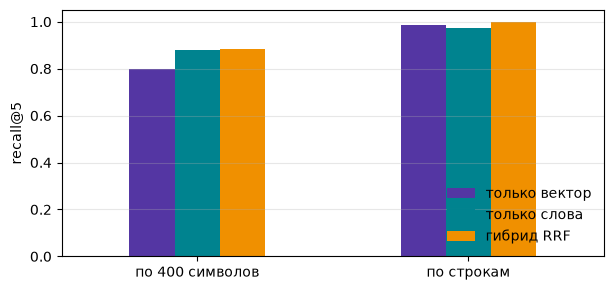

In [10]:
rows = []
for cut, chunks, ranked, texts in [("по 400 символов", char_chunks, rank_chars, [c["text"] for c in char_chunks]),
                                   ("по строкам", line_chunks, rank_lines, [emb_text(c) for c in line_chunks])]:
    docs, idf = build_keyword_index(texts)
    by_words = [keyword_search(t["question"], docs, idf, 20) for t in tasks]
    by_hybrid = [rrf([v, w], 20) for v, w in zip(ranked, by_words)]
    for name, r in [("только вектор", ranked), ("только слова", by_words), ("гибрид RRF", by_hybrid)]:
        rows.append({"нарезка": cut, "поиск": name, **{f"recall@{k}": round(recall_at(r, chunks, tasks, k), 3) for k in KS}})
hybrid = pd.DataFrame(rows)
hybrid.to_csv(RESULTS / "hybrid.csv", index=False)
hybrid_chart(hybrid, path=IMG / "hybrid.png", metric="recall@5")
hybrid

## Шаг 5. RAG-ответ, агент с knowledge_base и замер

`RagAnswerer` кладёт k найденных кусков в контекст с номерами и просит ответить только по ним, `NOT_FOUND` если ответа нет. `AgentAnswerer` даёт агенту из первой домашки инструмент `knowledge_base(query, page)`: модель сама решает, что и сколько раз искать. Прогоны на всех 148 вопросах и 10 вопросах без ответа сделаны скриптом `run_eval.py` и закэшированы в `results/`; здесь один живой пример каждого и чтение результатов.

In [11]:
rag = RagAnswerer(client, retriever, k=K)
out = rag(tasks[0]["question"], MODELS["cheap"])
print(out["answer"], "| эталон:", tasks[0]["answer"], "| цена, центов:", round(out["cost"] * 100, 4))

15 March 

FINAL: 15 March | эталон: 15 March | цена, центов: 0.0063


In [12]:
registry = make_registry(retriever, K)
print(json.dumps(registry["knowledge_base"].schema, ensure_ascii=False, indent=1))
agent_fn = AgentAnswerer(client, registry)
out = agent_fn(tasks[3]["question"], MODELS["cheap"])
print(final_answer(out["answer"]), "| эталон:", tasks[3]["answer"], "| обращений к базе:", out["searches"], "| цена, центов:", round(out["cost"] * 100, 4))

{
 "type": "function",
 "function": {
  "name": "knowledge_base",
  "description": "Searches the local knowledge base of 2026 events, built from Wikipedia year pages, and returns the five closest facts with their page and section. Use a short English query with names, places, dates and key terms of the event.",
  "parameters": {
   "properties": {
    "query": {
     "description": "short search query in English: names, dates, key terms of the event",
     "title": "Query",
     "type": "string"
    },
    "page": {
     "default": "",
     "description": "optional exact page title to search within, for example '2026 in Japan'; empty means all pages",
     "title": "Page",
     "type": "string"
    }
   },
   "required": [
    "query"
   ],
   "title": "KBArgs",
   "type": "object"
  }
 }
}


12  March, strategic partnership agreement in the defense and energy sectors. | эталон: a strategic partnership agreement | обращений к базе: 1 | цена, центов: 0.0146


In [13]:
names = {"plain_sonnet": "сильная модель, без инструментов", "plain_cheap": "дешёвая модель, без инструментов",
         "rag_cheap": "дешёвая модель, RAG всегда, k=5", "agent_cheap": "дешёвая модель, агент с knowledge_base",
         "rag_mid": "средняя модель, RAG всегда, k=5", "rag_cheap_v2": "дешёвая модель, RAG всегда, k=5, промпт v2"}
frames, none_frames = [], []
for name, label in names.items():
    df, dn = pd.read_csv(RESULTS / f"{name}.csv"), pd.read_csv(RESULTS / f"{name}_unanswerable.csv")
    df["config"], dn["config"] = label, label
    frames.append(df); none_frames.append(dn)
live = last_week_rows(tasks, WEEK1 / "results" / "results_all.csv", "поиск + страница v2", "gpt-4o-mini", "дешёвая модель, живой поиск (1-я домашка)")
results = pd.concat(frames[:1] + [live] + frames[1:], ignore_index=True)
none_results = pd.concat(none_frames, ignore_index=True)
table = report(results)
table.to_csv(RESULTS / "report.csv", index=False)
(RESULTS / "report.md").write_text(table.to_markdown(index=False), encoding="utf-8")
table

,config,model,n,accuracy,cost_per_task,avg_searches,cost_per_correct
0,"сильная модель, без инструментов",claude-sonnet-4.6,148,0.01351,0.00089,0.00000,0.06596
1,"дешёвая модель, живой поиск (1-я домашка)",gpt-4o-mini,148,0.68243,0.00060,2.97297,0.00088
2,"дешёвая модель, без инструментов",gpt-4o-mini,148,0.00676,0.00002,0.00000,0.00298
3,"дешёвая модель, RAG всегда, k=5",gpt-4o-mini,148,0.83108,0.00006,1.00000,0.00007
4,"дешёвая модель, агент с knowledge_base",gpt-4o-mini,148,0.84459,0.00022,1.36486,0.00027
5,"средняя модель, RAG всегда, k=5",claude-haiku-4.5,148,0.89865,0.00063,1.00000,0.00070
6,"дешёвая модель, RAG всегда, k=5, промпт v2",gpt-4o-mini,148,0.91892,0.00007,1.00000,0.00007


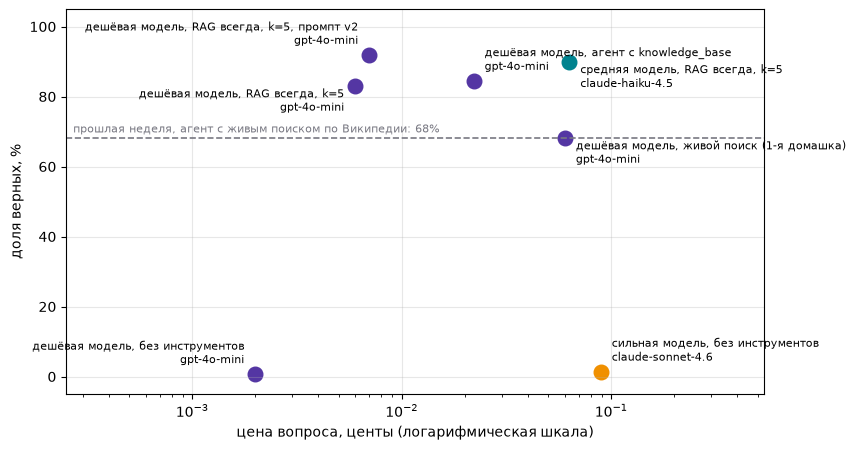

In [14]:
last_week = float(live["correct"].mean())
money_chart(table, IMG / "money.png", baseline=(f"прошлая неделя, агент с живым поиском по Википедии: {last_week:.0%}", last_week));

In [15]:
refusals = refusal_table(results[results["config"].isin(names.values())], none_results)
refusals.to_csv(RESULTS / "refusals.csv", index=False)
(RESULTS / "refusals.md").write_text(refusals.to_markdown(index=False), encoding="utf-8")
refusals

,config,model,отклонено без ответа,отклонено зря,доля отказов зря
0,"сильная модель, без инструментов",claude-sonnet-4.6,10 из 10,139 из 148,0.939
1,"дешёвая модель, без инструментов",gpt-4o-mini,10 из 10,109 из 148,0.736
2,"дешёвая модель, RAG всегда, k=5",gpt-4o-mini,10 из 10,2 из 148,0.014
3,"дешёвая модель, агент с knowledge_base",gpt-4o-mini,10 из 10,5 из 148,0.034
4,"средняя модель, RAG всегда, k=5",claude-haiku-4.5,10 из 10,3 из 148,0.020
5,"дешёвая модель, RAG всегда, k=5, промпт v2",gpt-4o-mini,10 из 10,2 из 148,0.014


медиана близости лучшего куска: с ответом 0.761, без ответа 0.575


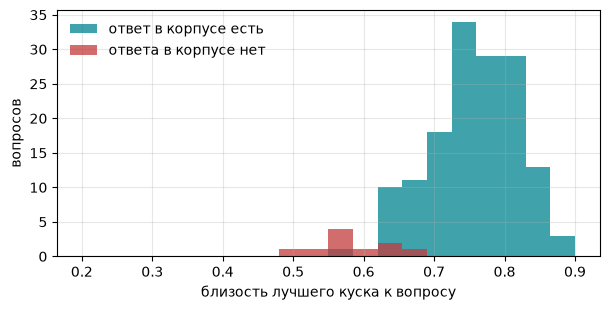

In [16]:
top_answerable = [search_numpy(q, line_vecs, 1)[0][1] for q in q_vecs]
top_unanswerable = [search_numpy(q, line_vecs, 1)[0][1] for q in cache.embed([t["question"] for t in unanswerable])]
similarity_chart(top_answerable, top_unanswerable, path=IMG / "similarity.png")
print("медиана близости лучшего куска: с ответом %.3f, без ответа %.3f" % (np.median(top_answerable), np.median(top_unanswerable)))

## Шаг 6. Разбор провалов лучшей дешёвой конфигурации

Две кучки: «поиск не нашёл» (верного куска нет среди найденных) и «нашёл, но ответ неверный». Для каждой кучки один пример с тем, что было в контексте.

In [17]:
best = max(names.values(), key=lambda c: table[(table["config"] == c) & (table["model"] == "gpt-4o-mini")]["accuracy"].max() if "дешёвая" in c else -1)
print("лучшая дешёвая конфигурация:", best)
diag = diagnose(results, best, "gpt-4o-mini")
{k: v for k, v in diag.items() if not k.startswith("ids")}

лучшая дешёвая конфигурация: дешёвая модель, RAG всегда, k=5, промпт v2


{'всего провалов': 12, 'поиск не нашёл': 1, 'нашёл, но ответ неверный': 11}

In [18]:
traces_name = next(n for n, l in names.items() if l == best)
traces = {t["task"]["id"]: t for t in map(json.loads, (RESULTS / f"{traces_name}_traces.jsonl").read_text(encoding="utf-8").splitlines())}
def show_failure(tid):
    t = traces[tid]
    print("вопрос:", t["task"]["question"], "\nэталон:", t["task"]["answer"], "| цитата:", t["task"]["evidence"][:160])
    print("ответ модели:", final_answer(t["answer"]), "| поисков:", t.get("searches"))
    for h in t["hits"][:5]:
        print(f"  [{h['page']} / {h['section']}] {h['score']} {h['text'][:150]}")
print("=== поиск не нашёл ==="); show_failure(diag["ids не нашёл"][0])
print("\n=== нашёл, но ответ неверный ==="); show_failure(diag["ids нашёл"][0])

=== поиск не нашёл ===
вопрос: Who entered negotiations with the Trump administration on March 13, 2026? 
эталон: Miguel Díaz-Canel | цитата: March 13 - First Secretary of the Communist Party of Cuba Miguel Díaz-Canel entered negotiations with the Trump administration in an effort to end the United St
ответ модели: NOT_FOUND | поисков: 1
  [2026 in the United States / September] 0.624 Trump announces that he is willing to engage with Iran to negotiate a deal.
  [2026 in the United States / September] 0.6083 September 27 – Trump says that he still expected more talks to resume with Iran during the week. Trump claims that Iran "wanted to make a deal," but t
  [2026 in the United States / April] 0.5877 Trump says that he extended the Iran truce to allow time for an Iranian proposal to be submitted at Pakistan's request.
  [2026 in the United States / May] 0.5747 President Trump announces that Operation Project Freedom has been paused, citing progress in negotiations.
  [2026 in the United

In [19]:
failures = results[(results["config"] == best) & (results["model"] == "gpt-4o-mini") & ~results["correct"]][["id", "found", "refused", "answer", "gold"]]
failures.to_csv(RESULTS / "failures_best.csv", index=False)
failures.head(20)

,id,found,refused,answer,gold
890,fresh-2,False,True,NOT_FOUND,Miguel Díaz-Canel
916,fresh-29,True,False,46 people,43
919,fresh-32,True,False,Iluwanti Ken,Richard Lewer
928,fresh-42,True,False,Narendra Modi,Prime Minister Narendra Modi
952,fresh-66,True,False,6 people,at least six
973,fresh-87,True,True,NOT_FOUND,José Jerí
986,fresh-100,True,False,"252,757 miles","252,756 miles"
987,fresh-101,True,False,10 days,10-day
988,fresh-102,True,False,Viktor Kuzmenko,Oleksandr Dovhach
993,fresh-107,True,False,11 January,2026 Beninese parliamentary election


## Шаг 7. Память агента

Эпизодическая память: журнал всех реплик в `data/episodes.jsonl` с сессией и временем, в контекст он не идёт. Семантическая: факты о пользователе, которые дешёвая модель извлекает в конце сессии и возвращает полным обновлённым списком, поэтому новый факт заменяет старый. Факты лежат в отдельной коллекции Milvus `facts`, к вопросу достаются три ближайших. Поиск по корпусу делается дважды, по вопросу и по вопросу с фактами, и списки сливаются через RRF.

In [20]:
journal = EpisodicJournal(DATA / "episodes.jsonl")
memory = SemanticMemory(store, cache.embed, "facts", DATA / "facts.json")
journal.clear(); memory.clear()
assistant = MemoryAssistant(client, retriever, memory, journal, MODELS["cheap"])
first = []
print(assistant.talk("s1", first, "Привет! Я Лена, продуктовый аналитик из Новосибирска. Слежу за космосом и хоккеем, отвечай коротко."))
print(assistant.talk("s1", first, "Что было в космосе в июле 2026 года?"))
print("\nфакты после первой сессии:", assistant.end_session(first))

Привет, Лена! Какой именно вопрос о событиях 2026 года тебя интересует? К сожалению, у меня нет источников, но я постараюсь помочь!


В июле 2026 года произошло два значительных события в космосе. Китайский космический аппарат Tianwen-2 достиг близкой к Земле астероида Kamoʻoalewa для сбора образцов. Также японский космический аппарат Hayabusa2 пролетел мимо близкой к Земле астероида Torifune. Это были первые близкие наблюдения за этими новыми объектами солнечной системы.



факты после первой сессии: ['имя: Лена', 'город: Новосибирск', 'работа: продуктовый аналитик', 'интересы: космос, хоккей', 'пожелания к ответам: отвечай коротко']


In [21]:
second = []
print(assistant.talk("s2", second, "Что интересного случилось в моих темах за лето?"))
print(assistant.talk("s2", second, "Хоккей я забросила, теперь слежу за футболом. И я переехала в Калининград."))
print(assistant.talk("s2", second, "Кто выиграл чемпионат мира по футболу 2026?"))
print("\nфакты после второй сессии:", assistant.end_session(second))
print("что вспоминается на вопрос «где теперь живёт Лена?»:", memory.recall("где теперь живёт Лена, в каком городе?", 2))
pd.DataFrame(journal.read())[["session", "time", "role", "text"]].assign(text=lambda d: d["text"].str[:80])

Лена, в 2026 году летом интересные события произошли в области космоса. В частности, в июле было восстановлено наблюдение с экспериментальной миссии ESA PROBA-3 после потери контакта с одним из двух космических аппаратов в феврале. Это событие может быть интересным для тебя как любительницы космоса, поскольку программа связана с исследованием солнечной активности.

Что касается хоккея, в источниках нет никаких упоминаний о значимых событиях за лето 2026 года. Если у тебя есть более конкретные вопросы или интересы, дай знать!


Поняла, Лена! Теперь, когда ты заинтересовалась футболом, давай посмотрим, что нового произошло летом 2026 года в этой сфере. Несмотря на отсутствие конкретной информации в источниках, в этом году проходил чемпионат мира по футболу, который привлек много внимания. 

Если есть какие-то специфические события или вопросы, которые тебя интересуют, дай знать!


Чемпионат мира по футболу 2026 года выиграла Испания. Это было их второе чемпионство, и турнир проходил с 11 июня по 19 июля 2026 года, впервые принимая участие 48 команд.



факты после второй сессии: ['имя: Лена', 'город: Калининград', 'работа: продуктовый аналитик', 'интересы: космос, футбол', 'пожелания к ответам: отвечай коротко']


что вспоминается на вопрос «где теперь живёт Лена?»: ['имя: Лена', 'город: Калининград']


,session,time,role,text
0,s1,2026-09-28 00:17:27,user,"Привет! Я Лена, продуктовый аналитик из Новоси..."
1,s1,2026-09-28 00:17:34,assistant,"Привет, Лена! Какой именно вопрос о событиях 2..."
2,s1,2026-09-28 00:17:34,user,Что было в космосе в июле 2026 года?
3,s1,2026-09-28 00:17:42,assistant,В июле 2026 года произошло два значительных со...
4,s2,2026-09-28 00:17:57,user,Что интересного случилось в моих темах за лето?
5,s2,2026-09-28 00:18:10,assistant,"Лена, в 2026 году летом интересные события про..."
6,s2,2026-09-28 00:18:10,user,"Хоккей я забросила, теперь слежу за футболом. ..."
7,s2,2026-09-28 00:18:16,assistant,"Поняла, Лена! Теперь, когда ты заинтересовалас..."
8,s2,2026-09-28 00:18:16,user,Кто выиграл чемпионат мира по футболу 2026?
9,s2,2026-09-28 00:18:28,assistant,Чемпионат мира по футболу 2026 года выиграла И...


**График токенов.** Один и тот же диалог из десяти вопросов двумя способами: «вся история в контексте» и «окно из четырёх сообщений плюс факты». Считаем токены на входе по репликам и суммарную цену.

,реплик,токенов_на_входе,цена
tag,,,
dialog: память,10,4744,0.00094
dialog: вся история,10,16549,0.00177


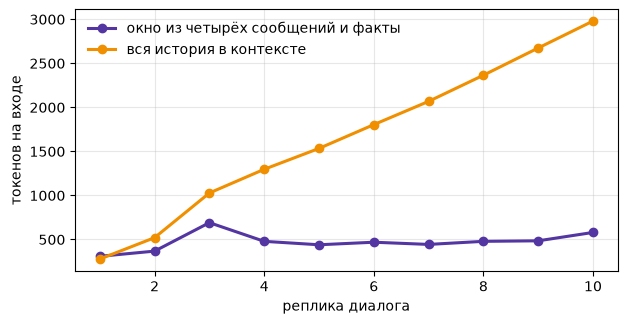

In [22]:
SCRIPT = [t["question"] for t in tasks[40:50]]
for mode in ("память", "вся история"):
    history = []
    for q in SCRIPT:
        assistant.talk("bench", history, q, mode)
per_turn = pd.DataFrame([c for c in ledger.calls if c["tag"].startswith("dialog: ")][-2 * len(SCRIPT):])
tokens_chart(per_turn, path=IMG / "memory_tokens.png")
memory_cost = per_turn.groupby("tag", sort=False).agg(реплик=("prompt", "size"), токенов_на_входе=("prompt", "sum"), цена=("cost", "sum")).round(5)
memory_cost.to_csv(RESULTS / "memory_tokens.csv")
memory_cost

## Бонус: тот же конвейер на PDF

Лекции курса и текст этого задания режутся по страницам, имя файла и номер страницы едут метаданными, ответ ссылается на файл и страницу.

In [23]:
from rag.pdf import pdf_corpus, COURSE_SYSTEM
pdf = pdf_corpus(Path.cwd())
print("страниц в PDF-корпусе:", len(pdf), "| файлы:", sorted({c["page"] for c in pdf}))
store.index("course", pdf, cache.embed([emb_text(c) for c in pdf])); cache.save()
pdf_retriever = Retriever(store, cache, "course", 3)
course_rag = RagAnswerer(client, pdf_retriever, k=3, system=COURSE_SYSTEM, tag="pdf")
for q in ["Что такое RRF и зачем он нужен?", "Сколько баллов дают за память: две сессии, замену факта, график токенов и тесты без модели?",
          "Во сколько центов обошёлся весь прогон семинарского ноутбука и сколько из них съела сильная модель?"]:
    out = course_rag(q, MODELS["cheap"])
    print(q, "\n ", " ".join(out["answer"].split())[:300], "\n  источники:", [(h["page"], h["section"]) for h in out["hits"]], "\n")

страниц в PDF-корпусе: 80 | файлы: ['homework02.pdf', 'lecture04.pdf', 'lecture05.pdf', 'lecture06.pdf']


Что такое RRF и зачем он нужен? 
  RRF (Reciprocal Rank Fusion) — это метод, который объединяет ранги элементов из разных списков, суммируя обратные позиции. Он нужен для гибридного поиска, чтобы комбинировать результаты, учитывая как качество векторного поиска, так и точность поиска по словам, что позволяет извлекать лучшие результа 
  источники: [('lecture06.pdf', 'стр. 14'), ('lecture06.pdf', 'стр. 19'), ('lecture05.pdf', 'стр. 24')] 



Сколько баллов дают за память: две сессии, замену факта, график токенов и тесты без модели? 
  За память: две сессии, замену факта, график токенов и тесты без модели дают 2 балла. [1, страница 3] FINAL: 2 
  источники: [('homework02.pdf', 'стр. 3'), ('lecture04.pdf', 'стр. 25'), ('lecture04.pdf', 'стр. 20')] 



Во сколько центов обошёлся весь прогон семинарского ноутбука и сколько из них съела сильная модель? 
  NOT_FOUND. FINAL: NOT_FOUND 
  источники: [('lecture05.pdf', 'стр. 19'), ('homework02.pdf', 'стр. 2'), ('lecture06.pdf', 'стр. 25')] 



In [24]:
ledger.table(), round(ledger.total, 4)

(                                            calls  prompt  completion  \
 tag                 model                                               
 agent               gpt-4o-mini                 2     817          39   
 dialog: вся история gpt-4o-mini                10   16549         389   
 dialog: память      gpt-4o-mini                15    6922         767   
 embed               text-embedding-3-small     18     885           0   
 memory              gpt-4o-mini                 2     764         101   
 pdf                 gpt-4o-mini                 3    3625         135   
 rag                 gpt-4o-mini                 1     386           8   
 
                                                cost  seconds  
 tag                 model                                     
 agent               gpt-4o-mini             0.00015    12.06  
 dialog: вся история gpt-4o-mini             0.00177    77.25  
 dialog: память      gpt-4o-mini             0.00150   107.07  
 embed      